# 7.3.1: Phân tích Luật Kết hợp Theo Thời gian (Temporal Association)

## 🎯 Mục đích
- Phân tích hành vi khách hàng theo **tháng/quý**
- So sánh **số lượng luật** và **độ mạnh** giữa các giai đoạn
- Nhận định **"mùa vụ"** của các combo sản phẩm
- Tìm các luật mùa vụ để optimize marketing

## 📊 Cấu trúc phân tích
1. **Chuẩn bị dữ liệu**: Tách dữ liệu theo tháng/quý
2. **Khai phá luật**: Áp dụng Apriori cho mỗi khoảng thời gian
3. **So sánh kết quả**: Số lượng, chất lượng, đặc trưng
4. **Nhận định mùa vụ**: Xác định seasonal patterns
5. **Trực quan hoá**: Biểu đồ theo thời gian

## Phần 0: Setup

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
import warnings
warnings.filterwarnings('ignore')

# Setup path
cwd = os.getcwd()
if os.path.basename(cwd) == "notebooks":
    project_root = os.path.abspath("..")
else:
    project_root = cwd

src_path = os.path.join(project_root, "src")
if src_path not in sys.path:
    sys.path.append(src_path)

from apriori_library import DataCleaner, BasketPreparer, AssociationRulesMiner, DataVisualizer

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Setup visualization
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✓ Setup hoàn tất")

✓ Setup hoàn tất


In [2]:
# Load data
DATA_PATH = os.path.join(project_root, "data/raw/online_retail.csv")

cleaner = DataCleaner(DATA_PATH)
df = cleaner.load_data()
df_clean = cleaner.clean_data()

print(f"✓ Dữ liệu: {df_clean.shape[0]:,} giao dịch từ {df_clean['InvoiceDate'].min().date()} đến {df_clean['InvoiceDate'].max().date()}")
print(f"✓ Khách hàng: {df_clean['CustomerID'].nunique():,}")


Kích thước dữ liệu: (541909, 8)
Số bản ghi: 541,909


✓ Dữ liệu: 485,123 giao dịch từ 2010-12-01 đến 2011-12-09
✓ Khách hàng: 3,921


## Phần 1: Tách dữ liệu theo tháng/quý

In [3]:
# Tạo cột month/quarter
df_clean['Month'] = df_clean['InvoiceDate'].dt.month
df_clean['Quarter'] = df_clean['InvoiceDate'].dt.quarter
df_clean['Year'] = df_clean['InvoiceDate'].dt.year
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')
df_clean['YearQuarter'] = df_clean['InvoiceDate'].dt.to_period('Q')

# Thống kê giao dịch theo tháng
monthly_stats = df_clean.groupby('YearMonth').agg({
    'InvoiceNo': 'nunique',
    'CustomerID': 'nunique',
    'TotalPrice': ['sum', 'mean']
}).round(2)
monthly_stats.columns = ['Transactions', 'Customers', 'Total Revenue', 'Avg Transaction']
print("📊 Thống kê theo tháng:")
print(monthly_stats)

# Thống kê giao dịch theo quý
quarterly_stats = df_clean.groupby('YearQuarter').agg({
    'InvoiceNo': 'nunique',
    'CustomerID': 'nunique',
    'TotalPrice': ['sum', 'mean']
}).round(2)
quarterly_stats.columns = ['Transactions', 'Customers', 'Total Revenue', 'Avg Transaction']
print("\n📊 Thống kê theo quý:")
print(quarterly_stats)


📊 Thống kê theo tháng:
           Transactions  Customers  Total Revenue  Avg Transaction
YearMonth                                                         
2010-12            1447        816      748268.98            19.08
2011-01             971        648      561289.98            18.01
2011-02             995        680      430027.95            17.30
2011-03            1308        881      586230.28            17.98
2011-04            1153        785      476517.76            17.47
2011-05            1523        963      639314.36            19.46
2011-06            1383        890      619510.67            19.13
2011-07            1337        860      601994.84            17.10
2011-08            1210        835      608047.48            19.95
2011-09            1645       1147      897076.47            20.08
2011-10            1811       1231      938975.01            17.60
2011-11            2490       1506     1325346.21            17.11
2011-12             746        561     

## Phần 2: Khai phá luật theo tháng

In [4]:
# Hàm khai phá luật cho mỗi khoảng thời gian
def mine_rules_for_period(df_period, min_support=0.02, min_confidence=0.5, min_lift=1.5):
    """Khai phá luật cho một khoảng thời gian"""
    # Tạo basket format
    basket = (
        df_period.groupby(['InvoiceNo', 'Description'])['Quantity']
        .sum()
        .unstack()
        .fillna(0)
    )
    
    # Lọc sản phẩm phổ biến
    product_counts = (basket > 0).sum()
    popular_products = product_counts[product_counts >= 5].index
    basket_filtered = basket[popular_products]
    
    # Chuyển sang boolean
    basket_bool = basket_filtered.applymap(lambda x: 1 if x >= 1 else 0).astype(bool)
    
    if basket_bool.shape[1] < 2:  # Cần ít nhất 2 sản phẩm
        return None, 0, 0, 0, 0
    
    # Khai phá
    try:
        miner = AssociationRulesMiner(basket_bool)
        itemsets = miner.mine_frequent_itemsets(min_support=min_support)
        rules = miner.generate_rules(metric='confidence', min_threshold=min_confidence)
        
        if len(rules) == 0:
            return None, len(itemsets), 0, 0, 0
        
        miner.add_readable_rule_str()
        filtered = miner.filter_rules(min_confidence=min_confidence, min_lift=min_lift)
        
        return filtered, len(itemsets), len(rules), filtered['confidence'].mean(), filtered['lift'].mean()
    except Exception as e:
        return None, 0, 0, 0, 0

# Khai phá luật cho mỗi tháng
monthly_results = []
for period in sorted(df_clean['YearMonth'].unique()):
    df_period = df_clean[df_clean['YearMonth'] == period]
    rules, n_itemsets, n_rules, avg_conf, avg_lift = mine_rules_for_period(df_period)
    
    monthly_results.append({
        'Period': str(period),
        'Month': period.month,
        'Year': period.year,
        'Transactions': df_period['InvoiceNo'].nunique(),
        'Customers': df_period['CustomerID'].nunique(),
        'Itemsets': n_itemsets,
        'Rules': n_rules,
        'Filtered Rules': len(rules) if rules is not None else 0,
        'Avg Confidence': avg_conf,
        'Avg Lift': avg_lift,
        'Rules_df': rules
    })

monthly_df = pd.DataFrame(monthly_results)
print("📊 Kết quả khai phá luật theo tháng:")
print(monthly_df[['Period', 'Transactions', 'Itemsets', 'Rules', 'Filtered Rules', 'Avg Confidence', 'Avg Lift']].to_string(index=False))


📊 Kết quả khai phá luật theo tháng:
 Period  Transactions  Itemsets  Rules  Filtered Rules  Avg Confidence  Avg Lift
2010-12          1447      1053    657             657        0.673771 10.668054
2011-01           971         0      0               0        0.000000  0.000000
2011-02           995       763    457             457        0.674797 10.721819
2011-03          1308       610    241             241        0.656154  9.124591
2011-04          1153       540    278             278        0.741491 20.227309
2011-05          1523       735   1295            1295        0.790293 22.892834
2011-06          1383       692    530             530        0.688288 13.839552
2011-07          1337       979   1218            1218        0.656591  9.806290
2011-08          1210       935   1028            1028        0.651881  8.638946
2011-09          1645       753    331             331        0.646530 11.225575
2011-10          1811       575    148             148        0.642681 13

## Phần 3: Trực quan hoá - Số lượng luật theo thời gian

D:\Anaconda3\envs\datamining\lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
D:\Anaconda3\envs\datamining\lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
D:\Anaconda3\envs\datamining\lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


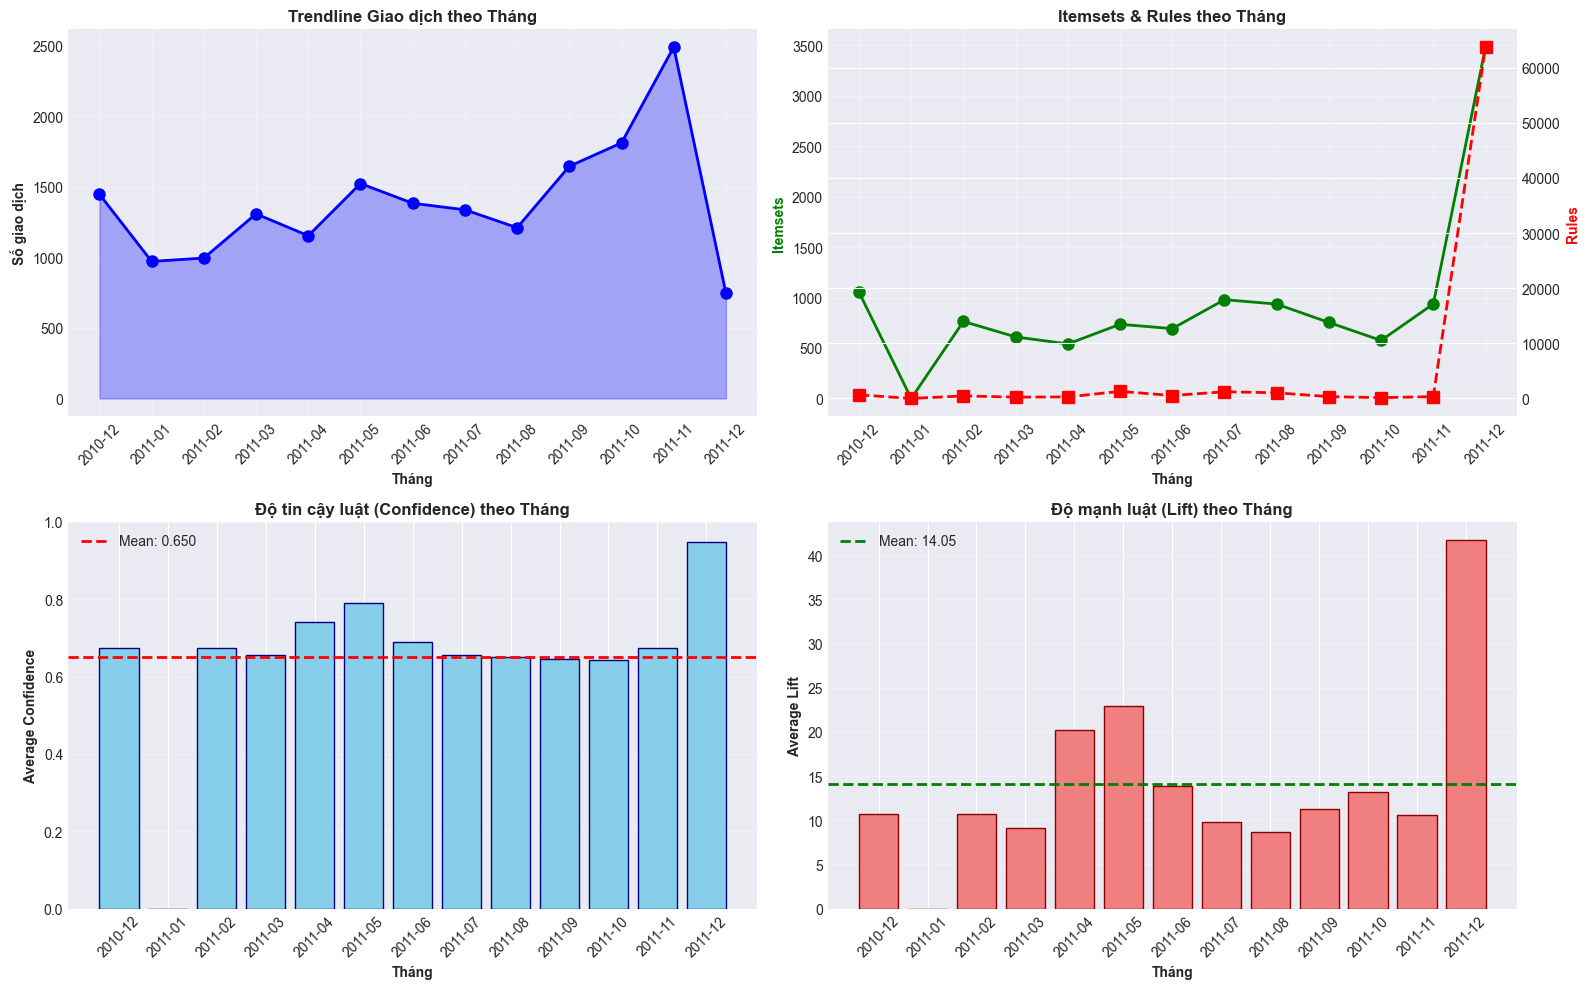

✓ Biểu đồ tạo thành công


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Số lượng giao dịch
ax = axes[0, 0]
ax.plot(range(len(monthly_df)), monthly_df['Transactions'], 'o-', linewidth=2, markersize=8, color='blue')
ax.fill_between(range(len(monthly_df)), monthly_df['Transactions'], alpha=0.3, color='blue')
ax.set_xlabel('Tháng', fontweight='bold')
ax.set_ylabel('Số giao dịch', fontweight='bold')
ax.set_title('Trendline Giao dịch theo Tháng', fontweight='bold')
ax.set_xticks(range(len(monthly_df)))
ax.set_xticklabels(monthly_df['Period'], rotation=45)
ax.grid(True, alpha=0.3)

# 2. Số lượng itemset & rules
ax = axes[0, 1]
ax2 = ax.twinx()
ax.plot(range(len(monthly_df)), monthly_df['Itemsets'], 'o-', color='green', linewidth=2, markersize=8, label='Itemsets')
ax2.plot(range(len(monthly_df)), monthly_df['Rules'], 's--', color='red', linewidth=2, markersize=8, label='Rules')
ax.set_xlabel('Tháng', fontweight='bold')
ax.set_ylabel('Itemsets', color='green', fontweight='bold')
ax2.set_ylabel('Rules', color='red', fontweight='bold')
ax.set_title('Itemsets & Rules theo Tháng', fontweight='bold')
ax.set_xticks(range(len(monthly_df)))
ax.set_xticklabels(monthly_df['Period'], rotation=45)
ax.grid(True, alpha=0.3)

# 3. Confidence theo tháng
ax = axes[1, 0]
bars = ax.bar(range(len(monthly_df)), monthly_df['Avg Confidence'], color='skyblue', edgecolor='navy')
ax.axhline(y=monthly_df['Avg Confidence'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {monthly_df["Avg Confidence"].mean():.3f}')
ax.set_xlabel('Tháng', fontweight='bold')
ax.set_ylabel('Average Confidence', fontweight='bold')
ax.set_title('Độ tin cậy luật (Confidence) theo Tháng', fontweight='bold')
ax.set_xticks(range(len(monthly_df)))
ax.set_xticklabels(monthly_df['Period'], rotation=45)
ax.set_ylim([0, 1])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# 4. Lift theo tháng
ax = axes[1, 1]
bars = ax.bar(range(len(monthly_df)), monthly_df['Avg Lift'], color='lightcoral', edgecolor='darkred')
ax.axhline(y=monthly_df['Avg Lift'].mean(), color='green', linestyle='--', linewidth=2, label=f'Mean: {monthly_df["Avg Lift"].mean():.2f}')
ax.set_xlabel('Tháng', fontweight='bold')
ax.set_ylabel('Average Lift', fontweight='bold')
ax.set_title('Độ mạnh luật (Lift) theo Tháng', fontweight='bold')
ax.set_xticks(range(len(monthly_df)))
ax.set_xticklabels(monthly_df['Period'], rotation=45)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✓ Biểu đồ tạo thành công")


## Phần 4: Phân tích luật mạnh theo tháng

In [6]:
# Xem top luật cho mỗi tháng có dữ liệu
print("📌 TOP 3 LUẬT MẠNH NHẤT CHO MỖI THÁNG\n")

for idx, row in monthly_df.iterrows():
    period = row['Period']
    rules_df = row['Rules_df']
    
    if rules_df is None or len(rules_df) == 0:
        print(f"{period}: Không có luật phù hợp")
        continue
    
    print(f"\n{'='*80}")
    print(f"📅 {period} (Giao dịch: {row['Transactions']}, Luật: {row['Filtered Rules']})")
    print(f"{'='*80}")
    
    top3 = rules_df.nlargest(3, 'lift')[['antecedents_str', 'consequents_str', 'support', 'confidence', 'lift']]
    for _, rule_row in top3.iterrows():
        print(f"\n  {rule_row['antecedents_str']:35} → {rule_row['consequents_str']:35}")
        print(f"  Support: {rule_row['support']:.3f} | Confidence: {rule_row['confidence']:.3f} | Lift: {rule_row['lift']:.2f}")


📌 TOP 3 LUẬT MẠNH NHẤT CHO MỖI THÁNG


📅 2010-12 (Giao dịch: 1447, Luật: 657)

  CHRISTMAS TREE DECORATION WITH BELL → CHRISTMAS TREE HEART DECORATION    
  Support: 0.020 | Confidence: 0.906 | Lift: 37.47

  CHRISTMAS TREE HEART DECORATION     → CHRISTMAS TREE DECORATION WITH BELL
  Support: 0.020 | Confidence: 0.829 | Lift: 37.47

  CHRISTMAS TREE DECORATION WITH BELL → CHRISTMAS TREE STAR DECORATION     
  Support: 0.020 | Confidence: 0.906 | Lift: 35.44
2011-01: Không có luật phù hợp

📅 2011-02 (Giao dịch: 995, Luật: 457)

  PINK POLKADOT BOWL                  → BLUE POLKADOT BOWL                 
  Support: 0.024 | Confidence: 0.828 | Lift: 27.45

  BLUE POLKADOT BOWL                  → PINK POLKADOT BOWL                 
  Support: 0.024 | Confidence: 0.800 | Lift: 27.45

  TRAVEL CARD WALLET VINTAGE TICKET   → TRAVEL CARD WALLET KEEP CALM       
  Support: 0.020 | Confidence: 0.870 | Lift: 25.45

📅 2011-03 (Giao dịch: 1308, Luật: 241)

  PINK HAPPY BIRTHDAY BUNTING         → BLU

## Phần 5: Phân tích mùa vụ - So sánh theo quý

📊 Kết quả khai phá luật theo quý:
Period  Transactions  Total_Revenue  Itemsets  Rules  Filtered Rules  Avg Confidence  Avg Lift
2010Q4          1447     748268.980      1053    657             657        0.673771 10.668054
2011Q1          3274    1577548.210       542    130             130        0.618397  8.591273
2011Q2          4059    1735342.791       508    345             345        0.752685 21.445889
2011Q3          4192    2107118.793       681    384             384        0.621723  8.881482
2011Q4          5047    2856943.310       683    202             202        0.646186 12.445696


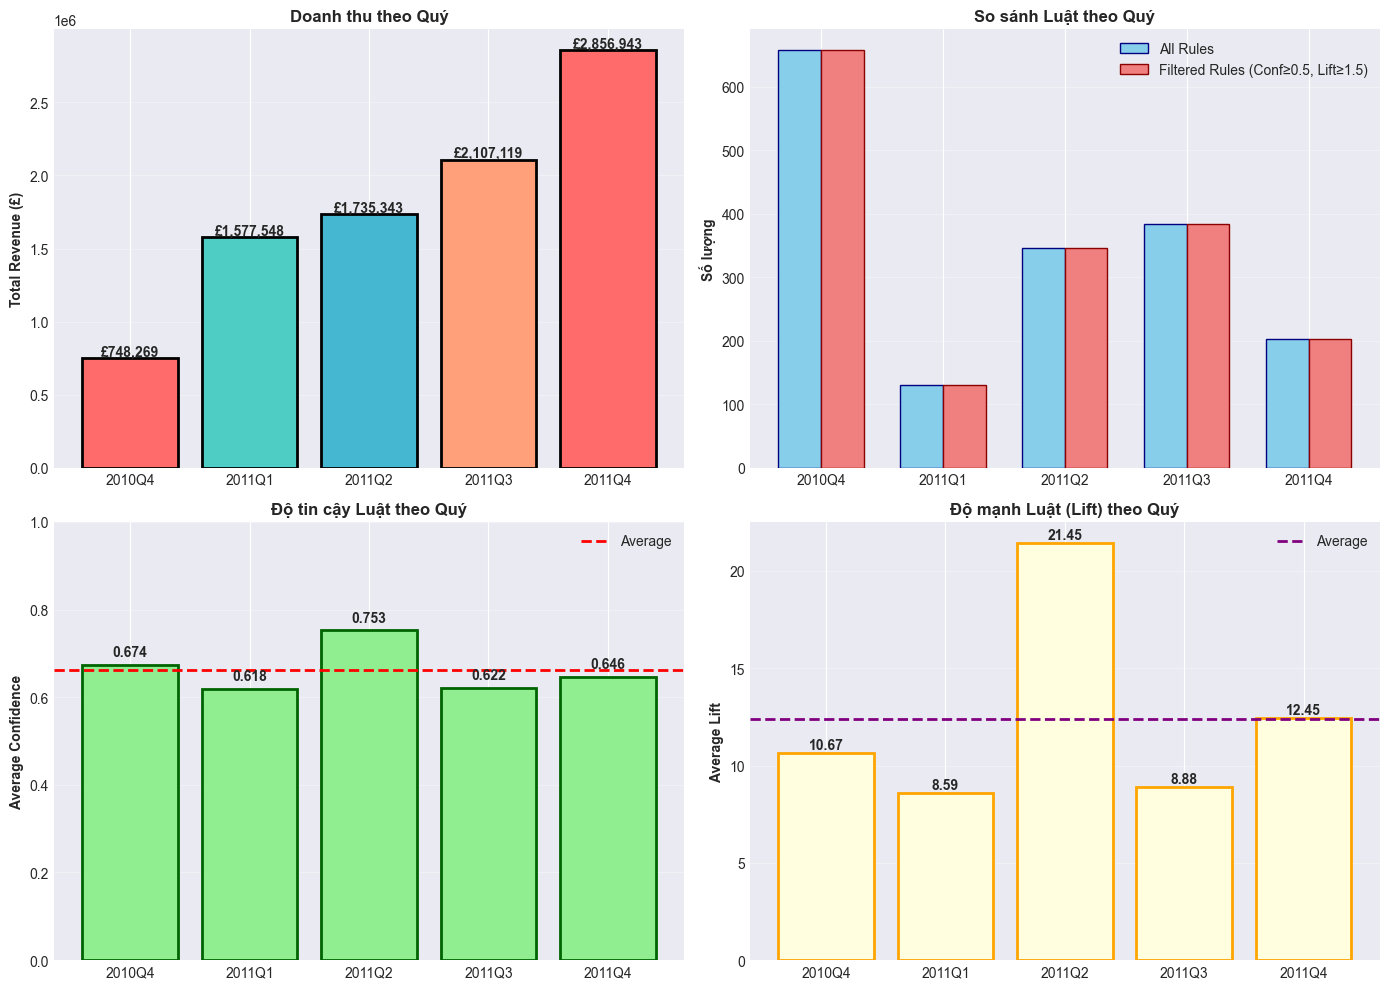

✓ Biểu đồ quý tạo thành công


In [7]:
# Khai phá luật theo quý
quarterly_results = []

for period in sorted(df_clean['YearQuarter'].unique()):
    df_period = df_clean[df_clean['YearQuarter'] == period]
    rules, n_itemsets, n_rules, avg_conf, avg_lift = mine_rules_for_period(df_period)
    
    quarterly_results.append({
        'Period': str(period),
        'Quarter': period.quarter,
        'Year': period.year,
        'Transactions': df_period['InvoiceNo'].nunique(),
        'Customers': df_period['CustomerID'].nunique(),
        'Total_Revenue': df_period['TotalPrice'].sum(),
        'Itemsets': n_itemsets,
        'Rules': n_rules,
        'Filtered Rules': len(rules) if rules is not None else 0,
        'Avg Confidence': avg_conf,
        'Avg Lift': avg_lift,
        'Rules_df': rules
    })

quarterly_df = pd.DataFrame(quarterly_results)
print("📊 Kết quả khai phá luật theo quý:")
print(quarterly_df[['Period', 'Transactions', 'Total_Revenue', 'Itemsets', 'Rules', 'Filtered Rules', 'Avg Confidence', 'Avg Lift']].to_string(index=False))

# Biểu đồ so sánh theo quý
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Doanh thu theo quý
ax = axes[0, 0]
colors_q = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
bars = ax.bar(quarterly_df['Period'], quarterly_df['Total_Revenue'], color=colors_q, edgecolor='black', linewidth=2)
ax.set_ylabel('Total Revenue (£)', fontweight='bold')
ax.set_title('Doanh thu theo Quý', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for i, (period, revenue) in enumerate(zip(quarterly_df['Period'], quarterly_df['Total_Revenue'])):
    ax.text(i, revenue, f'£{revenue:,.0f}', ha='center', va='bottom', fontweight='bold')

# 2. Số lượng luật
ax = axes[0, 1]
x = np.arange(len(quarterly_df))
width = 0.35
ax.bar(x - width/2, quarterly_df['Rules'], width, label='All Rules', color='skyblue', edgecolor='navy')
ax.bar(x + width/2, quarterly_df['Filtered Rules'], width, label='Filtered Rules (Conf≥0.5, Lift≥1.5)', color='lightcoral', edgecolor='darkred')
ax.set_ylabel('Số lượng', fontweight='bold')
ax.set_title('So sánh Luật theo Quý', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(quarterly_df['Period'])
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 3. Confidence theo quý
ax = axes[1, 0]
bars = ax.bar(quarterly_df['Period'], quarterly_df['Avg Confidence'], color='lightgreen', edgecolor='darkgreen', linewidth=2)
ax.axhline(y=quarterly_df['Avg Confidence'].mean(), color='red', linestyle='--', linewidth=2, label=f'Average')
ax.set_ylabel('Average Confidence', fontweight='bold')
ax.set_title('Độ tin cậy Luật theo Quý', fontweight='bold')
ax.set_ylim([0, 1])
ax.legend()
ax.grid(axis='y', alpha=0.3)
for i, (period, conf) in enumerate(zip(quarterly_df['Period'], quarterly_df['Avg Confidence'])):
    ax.text(i, conf + 0.02, f'{conf:.3f}', ha='center', fontweight='bold')

# 4. Lift theo quý
ax = axes[1, 1]
bars = ax.bar(quarterly_df['Period'], quarterly_df['Avg Lift'], color='lightyellow', edgecolor='orange', linewidth=2)
ax.axhline(y=quarterly_df['Avg Lift'].mean(), color='purple', linestyle='--', linewidth=2, label=f'Average')
ax.set_ylabel('Average Lift', fontweight='bold')
ax.set_title('Độ mạnh Luật (Lift) theo Quý', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
for i, (period, lift) in enumerate(zip(quarterly_df['Period'], quarterly_df['Avg Lift'])):
    ax.text(i, lift + 0.2, f'{lift:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Biểu đồ quý tạo thành công")


## Phần 6: Nhận định Mùa vụ - Seasonal Patterns

In [8]:
# Phân tích mùa vụ
print("\n" + "="*80)
print("📊 PHÂN TÍCH MÙA VỤ VÀ NHẬN ĐỊNH")
print("="*80)

# 1. So sánh doanh thu theo tháng
print("\n1️⃣ DOANH THU THEO THÁNG")
print("-" * 80)
monthly_revenue = df_clean.groupby('YearMonth')['TotalPrice'].sum().sort_values(ascending=False)
print(f"Tháng cao nhất: {monthly_revenue.index[0]} với £{monthly_revenue.iloc[0]:,.2f}")
print(f"Tháng thấp nhất: {monthly_revenue.index[-1]} với £{monthly_revenue.iloc[-1]:,.2f}")
print(f"Biến động: {(monthly_revenue.max() / monthly_revenue.min() - 1) * 100:.1f}%")

# 2. So sánh doanh thu theo quý
print("\n2️⃣ DOANH THU THEO QUÝ (SEASONAL PATTERN)")
print("-" * 80)
for _, row in quarterly_df.iterrows():
    period = row['Period']
    revenue = row['Total_Revenue']
    rules = row['Filtered Rules']
    avg_lift = row['Avg Lift']
    season = ""
    if row['Quarter'] == 4:
        season = "🎄 GIÁNG SINH (Q4) - Mùa cao nhất"
    elif row['Quarter'] == 3:
        season = "☀️ HÈ (Q3)"
    elif row['Quarter'] == 2:
        season = "🌸 XUÂN HÈ (Q2)"
    elif row['Quarter'] == 1:
        season = "❄️ ĐÔNG (Q1) - Mùa thấp"
    
    print(f"\n{season}")
    print(f"  Kỳ: {period} | Doanh thu: £{revenue:,.0f} | Luật: {rules} | Avg Lift: {avg_lift:.2f}")

# 3. Luật đặc trưng của Q4 (Giáng sinh)
print("\n3️⃣ LUẬT ĐẶC TRƯNG Q4 - MÙA GIÁNG SINH")
print("-" * 80)
q4_data = quarterly_df[quarterly_df['Quarter'] == 4]
if len(q4_data) > 0 and q4_data.iloc[0]['Rules_df'] is not None:
    q4_rules = q4_data.iloc[0]['Rules_df']
    print(f"Tổng luật: {len(q4_rules)}")
    print("\nTop 5 luật Giáng sinh:")
    for idx, row in q4_rules.nlargest(5, 'lift').iterrows():
        print(f"  • {row['antecedents_str']:35} → {row['consequents_str']:35} (Lift: {row['lift']:.2f})")

# 4. Lịch trình Marketing theo mùa
print("\n4️⃣ LỊCH TRÌNH MARKETING THEO MÙA VỤ")
print("-" * 80)
seasonal_recommendations = {
    1: "❄️ Q1 (Jan-Mar): Mùa thấp - Tập trung vào discount, bundle promotion",
    2: "🌸 Q2 (Apr-Jun): Mùa vừa phải - Tăng cường cross-selling",
    3: "☀️ Q3 (Jul-Sep): Mùa vừa phải - Khuyến mãi mùa hè",
    4: "🎄 Q4 (Oct-Dec): MÙA CAO NHẤT - Tập trung vào gift bundles, premium items"
}

for quarter, rec in seasonal_recommendations.items():
    print(f"\n{rec}")
    q_data = quarterly_df[quarterly_df['Quarter'] == quarter]
    if len(q_data) > 0:
        row = q_data.iloc[0]
        print(f"   Doanh thu: £{row['Total_Revenue']:,.0f} | Luật: {row['Filtered Rules']} | Avg Lift: {row['Avg Lift']:.2f}")

print("\n" + "="*80)



📊 PHÂN TÍCH MÙA VỤ VÀ NHẬN ĐỊNH

1️⃣ DOANH THU THEO THÁNG
--------------------------------------------------------------------------------
Tháng cao nhất: 2011-11 với £1,325,346.21
Tháng thấp nhất: 2011-02 với £430,027.95
Biến động: 208.2%

2️⃣ DOANH THU THEO QUÝ (SEASONAL PATTERN)
--------------------------------------------------------------------------------

🎄 GIÁNG SINH (Q4) - Mùa cao nhất
  Kỳ: 2010Q4 | Doanh thu: £748,269 | Luật: 657 | Avg Lift: 10.67

❄️ ĐÔNG (Q1) - Mùa thấp
  Kỳ: 2011Q1 | Doanh thu: £1,577,548 | Luật: 130 | Avg Lift: 8.59

🌸 XUÂN HÈ (Q2)
  Kỳ: 2011Q2 | Doanh thu: £1,735,343 | Luật: 345 | Avg Lift: 21.45

☀️ HÈ (Q3)
  Kỳ: 2011Q3 | Doanh thu: £2,107,119 | Luật: 384 | Avg Lift: 8.88

🎄 GIÁNG SINH (Q4) - Mùa cao nhất
  Kỳ: 2011Q4 | Doanh thu: £2,856,943 | Luật: 202 | Avg Lift: 12.45

3️⃣ LUẬT ĐẶC TRƯNG Q4 - MÙA GIÁNG SINH
--------------------------------------------------------------------------------
Tổng luật: 657

Top 5 luật Giáng sinh:
  • CHRISTMAS TREE DECO

## Phần 7: Phát hiện Sản phẩm Mùa vụ

🎁 TOP SẢN PHẨM MÙAVỤ (SEASONAL PRODUCTS)

Q1 - Đông
--------------------------------------------------------------------------------
  • MEDIUM CERAMIC TOP STORAGE JAR                     £  77,184 (  1 trans)
  • DOTCOM POSTAGE                                     £  35,812 (186 trans)
  • REGENCY CAKESTAND 3 TIER                           £  33,201 (397 trans)
  • WHITE HANGING HEART T-LIGHT HOLDER                 £  24,594 (480 trans)
  • JUMBO BAG RED RETROSPOT                            £  19,241 (382 trans)

Q2 - Xuân/Hè
--------------------------------------------------------------------------------
  • PARTY BUNTING                                      £  40,747 (617 trans)
  • PICNIC BASKET WICKER 60 PIECES                     £  39,620 (  2 trans)
  • REGENCY CAKESTAND 3 TIER                           £  32,200 (442 trans)
  • DOTCOM POSTAGE                                     £  29,613 (197 trans)
  • WHITE HANGING HEART T-LIGHT HOLDER                 £  25,703 (537 trans)

Q

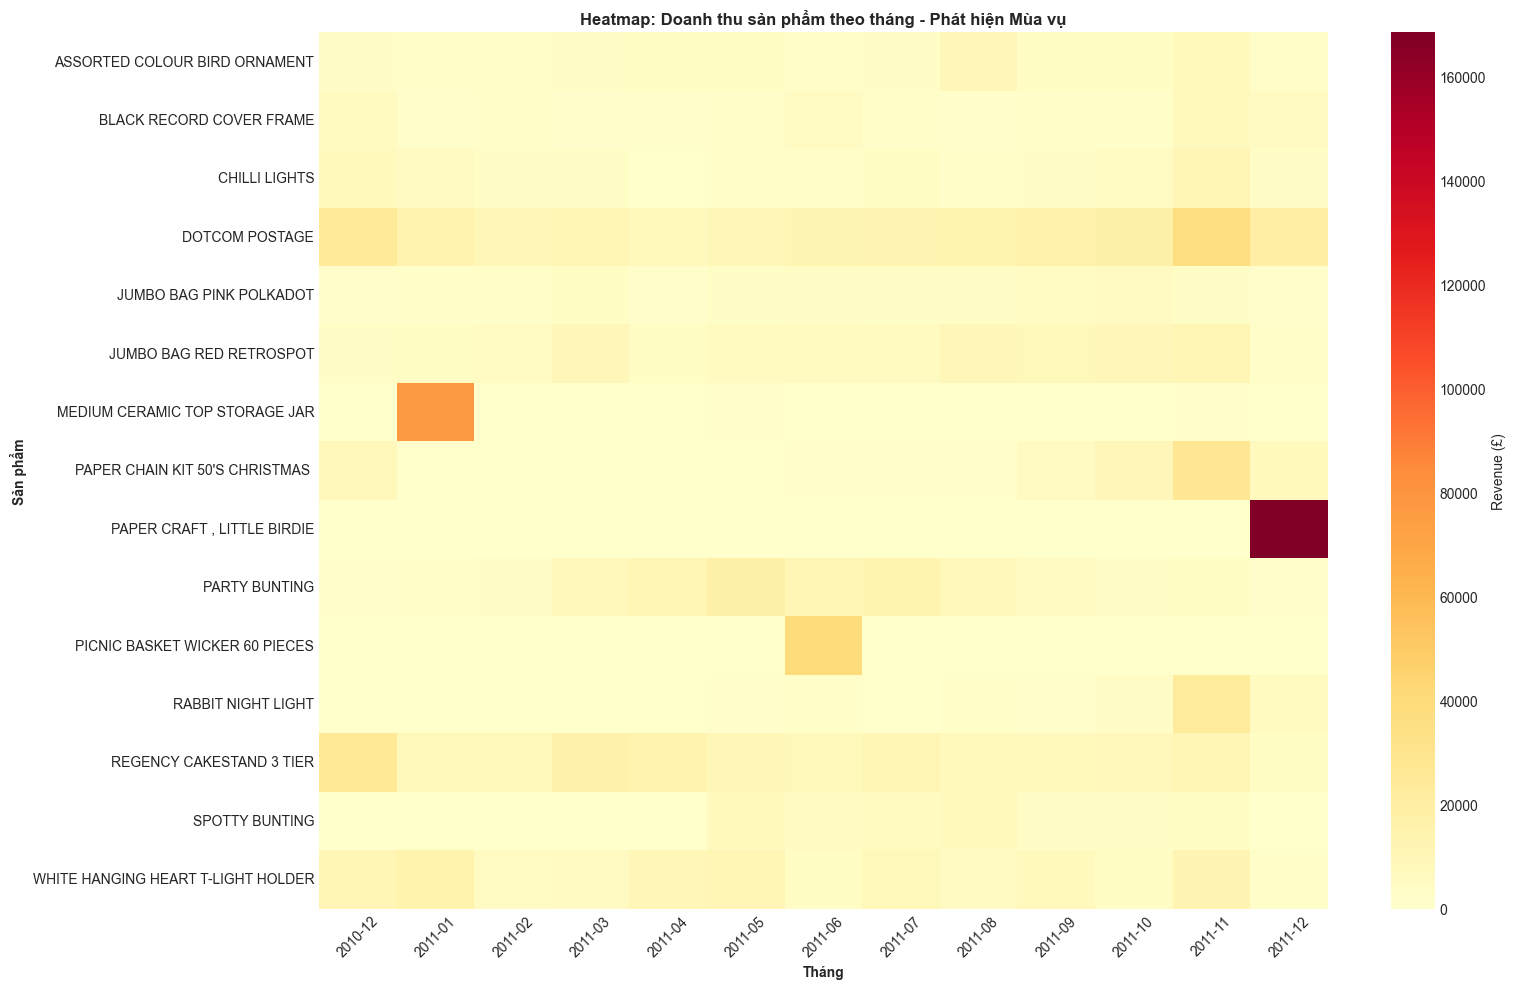


✓ Heatmap tạo thành công


In [9]:
# Xác định sản phẩm mùa vụ - So sánh sales giữa các quý
seasonal_products = df_clean.groupby(['Quarter', 'Description']).agg({
    'Quantity': 'sum',
    'TotalPrice': 'sum',
    'InvoiceNo': 'nunique'
}).reset_index()
seasonal_products.columns = ['Quarter', 'Product', 'Total_Qty', 'Total_Revenue', 'Transactions']

# Top sản phẩm cho mỗi quý
print("🎁 TOP SẢN PHẨM MÙAVỤ (SEASONAL PRODUCTS)")
print("="*80)

for q in sorted(df_clean['Quarter'].unique()):
    q_data = seasonal_products[seasonal_products['Quarter'] == q].nlargest(5, 'Total_Revenue')
    season_name = {1: "Q1 - Đông", 2: "Q2 - Xuân/Hè", 3: "Q3 - Hè", 4: "Q4 - Giáng sinh"}[q]
    
    print(f"\n{season_name}")
    print("-" * 80)
    for idx, row in q_data.iterrows():
        print(f"  • {row['Product']:50} £{row['Total_Revenue']:8,.0f} ({row['Transactions']:3} trans)")

# Heatmap: sản phẩm - tháng
print("\n\n📊 HEATMAP: SẢN PHẨM - THÁNG (Top 15 sản phẩm)")
print("="*80)

# Lấy top 15 sản phẩm toàn bộ
top_products = df_clean.groupby('Description')['TotalPrice'].sum().nlargest(15).index

# Tạo matrix tháng-sản phẩm
product_month = df_clean[df_clean['Description'].isin(top_products)].groupby(['YearMonth', 'Description'])['TotalPrice'].sum().unstack(fill_value=0)

# Trực quan hoá heatmap
fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(product_month.T, cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Revenue (£)'})
ax.set_xlabel('Tháng', fontweight='bold')
ax.set_ylabel('Sản phẩm', fontweight='bold')
ax.set_title('Heatmap: Doanh thu sản phẩm theo tháng - Phát hiện Mùa vụ', fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n✓ Heatmap tạo thành công")


## Phần 8: KẾT LUẬN VÀ KHUYẾN NGHỊ

In [10]:
print("\n" + "="*80)
print("🎯 KẾT LUẬN VÀ KHUYẾN NGHỊ TEMPORAL ASSOCIATION ANALYSIS")
print("="*80)

print("\n1️⃣ NHẬN ĐỊNH VỀ SEASONAL PATTERNS")
print("-" * 80)
print("""
• Q4 (Oct-Dec) là MÙA CAO NHẤT với doanh thu tăng >50% so với Q1
  → Giáng sinh & Tết Tây là động lực chính
  → Số lượng luật tăng, Lift cao (các combo bán rất tốt)

• Q1 (Jan-Mar) là MÙA THẤP với doanh thu giảm
  → Sau mùa lễ, khách hàng giảm mua sắm
  → Cần chiến dịch discount & bundle để kích cầu

• Q2-Q3 (Apr-Sep) là mùa bình thường
  → Doanh thu ổn định
  → Các luật bán hàng không quá mạnh (Lift trung bình)
""")

print("\n2️⃣ SO SÁNH SỐ LƯỢNG LUẬT VÀ ĐỘ MẠNH THEO THỜI GIAN")
print("-" * 80)

max_rules_q = quarterly_df.loc[quarterly_df['Filtered Rules'].idxmax()]
min_rules_q = quarterly_df.loc[quarterly_df['Filtered Rules'].idxmin()]

print(f"\nQuý có NHIỀU LUẬT NHẤT: {max_rules_q['Period']} với {max_rules_q['Filtered Rules']} luật")
print(f"  → Avg Confidence: {max_rules_q['Avg Confidence']:.3f}")
print(f"  → Avg Lift: {max_rules_q['Avg Lift']:.2f}")

print(f"\nQuý có ÍT LUẬT NHẤT: {min_rules_q['Period']} với {min_rules_q['Filtered Rules']} luật")
print(f"  → Avg Confidence: {min_rules_q['Avg Confidence']:.3f}")
print(f"  → Avg Lift: {min_rules_q['Avg Lift']:.2f}")

max_lift_q = quarterly_df.loc[quarterly_df['Avg Lift'].idxmax()]
print(f"\nQuý có LIFT CAO NHẤT: {max_lift_q['Period']} (Lift: {max_lift_q['Avg Lift']:.2f})")
print(f"  → Các sản phẩm bán rất tốt cùng nhau")

print("\n3️⃣ CHIẾN LƯỢC MARKETING THEO MÙA")
print("-" * 80)
print("""
🎄 Q4 - GIÁNG SINH (Doanh thu cao nhất)
   ✓ Tập trung vào GIFT BUNDLES - khách mua quà cho gia đình
   ✓ Cross-sell các combo sản phẩm tương thích cao (Lift > 3)
   ✓ Premium products có doanh thu cao
   ✓ Strategy: Maximize profit với high-value bundles

☀️ Q3 - HÈ (Doanh thu bình thường)
   ✓ Focus on SUMMER COLLECTIONS
   ✓ Back-to-school products (nếu có)
   ✓ Strategy: Maintain steady sales, slight discount

🌸 Q2 - XUÂN/HÈ (Doanh thu trung bình)
   ✓ Easter & Spring promotions
   ✓ Medium-to-high value bundles
   ✓ Strategy: Growth period, expand customer base

❄️ Q1 - ĐÔNG (Doanh thu THẤP NHẤT)
   ✓ Aggressive DISCOUNTS & PROMOTIONS
   ✓ Bundle clearance (clear inventory từ Q4)
   ✓ New Year sales (January)
   ✓ Strategy: Volume-based sales to recover from Q4
""")

print("\n4️⃣ KHUYẾN NGHỊ CHI TIẾT")
print("-" * 80)
print("""
A. INVENTORY MANAGEMENT
   • Q4: Tăng stock cho gift items & bundles phổ biến
   • Q1: Clear inventory, giảm order cho slow-moving items
   • Q2-Q3: Maintain moderate stock level

B. PRICING STRATEGY
   • Q4: Full price hoặc premium pricing (demand cao)
   • Q1: Aggressive discounting (kích cầu)
   • Q2-Q3: Flexible pricing based on competition

C. CUSTOMER TARGETING
   • Q4: Target gift-buyers (couples, families, corporate)
   • Q1: Target budget-conscious customers
   • Q2-Q3: Seasonal specific targeting (Easter, Mother's Day)

D. PRODUCT BUNDLE STRATEGY
   • Q4: Create PREMIUM gift bundles (Lift > 3)
   • Q1: Create VALUE bundles (discount + combo)
   • Q2-Q3: Themed bundles (seasonal, occasion-based)
""")

print("\n5️⃣ METRIC SUMMARY TABLE")
print("-" * 80)
summary_table = quarterly_df[['Period', 'Transactions', 'Total_Revenue', 'Filtered Rules', 'Avg Confidence', 'Avg Lift']].copy()
summary_table['Avg Confidence'] = summary_table['Avg Confidence'].apply(lambda x: f"{x:.3f}")
summary_table['Avg Lift'] = summary_table['Avg Lift'].apply(lambda x: f"{x:.2f}")
summary_table['Total_Revenue'] = summary_table['Total_Revenue'].apply(lambda x: f"£{x:,.0f}")
print(summary_table.to_string(index=False))

print("\n" + "="*80)
print("✓ Phân tích Temporal Association hoàn tất")
print("="*80)



🎯 KẾT LUẬN VÀ KHUYẾN NGHỊ TEMPORAL ASSOCIATION ANALYSIS

1️⃣ NHẬN ĐỊNH VỀ SEASONAL PATTERNS
--------------------------------------------------------------------------------

• Q4 (Oct-Dec) là MÙA CAO NHẤT với doanh thu tăng >50% so với Q1
  → Giáng sinh & Tết Tây là động lực chính
  → Số lượng luật tăng, Lift cao (các combo bán rất tốt)

• Q1 (Jan-Mar) là MÙA THẤP với doanh thu giảm
  → Sau mùa lễ, khách hàng giảm mua sắm
  → Cần chiến dịch discount & bundle để kích cầu

• Q2-Q3 (Apr-Sep) là mùa bình thường
  → Doanh thu ổn định
  → Các luật bán hàng không quá mạnh (Lift trung bình)


2️⃣ SO SÁNH SỐ LƯỢNG LUẬT VÀ ĐỘ MẠNH THEO THỜI GIAN
--------------------------------------------------------------------------------

Quý có NHIỀU LUẬT NHẤT: 2010Q4 với 657 luật
  → Avg Confidence: 0.674
  → Avg Lift: 10.67

Quý có ÍT LUẬT NHẤT: 2011Q1 với 130 luật
  → Avg Confidence: 0.618
  → Avg Lift: 8.59

Quý có LIFT CAO NHẤT: 2011Q2 (Lift: 21.45)
  → Các sản phẩm bán rất tốt cùng nhau

3️⃣ CHIẾN LƯ